# **Tourism Data Analysis – Exploratory Data Analysis (EDA)**

### **Project Type:** Data Analysis / Exploratory Data Analysis  
### **Dataset:** Tourism EDA Dataset  
### **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## **1. Introduction**

Tourism is an important contributor to economic activity through travel, accommodation, food, shopping, and other visitor-related spending. Understanding tourist profiles, travel behaviour, expenses, satisfaction, booking preferences, and repeat visitation can help tourism businesses and destination managers make better decisions.

This project performs an Exploratory Data Analysis (EDA) on a tourism dataset containing demographic, geographic, travel, accommodation, expense, satisfaction, booking, group-size, and repeat-visitor information.


## **2. Problem Statement**

Tourism businesses and destination managers need to understand who their visitors are, why they travel, how they travel, how much they spend, how satisfied they are, and whether they return.

This analysis explores tourist demographics, destinations, travel purposes, seasons, accommodation, expenses, satisfaction, booking behaviour, and repeat visitation to identify useful business patterns.


## **3. Objective of the Project**

1. Understand the demographic profile of tourists.
2. Identify popular countries, destinations, purposes, seasons, and travel modes.
3. Analyse tourist spending and major expense categories.
4. Study hotel preferences, ratings, and satisfaction.
5. Analyse seasonal and monthly tourism patterns.
6. Evaluate tourist satisfaction.
7. Understand online versus offline booking.
8. Analyse repeat visitors and compare them with non-repeat visitors.
9. Identify cities with stronger repeat-visitor behaviour.
10. Generate business insights and recommendations.


## **4. Business Questions**

### Tourist Profile
- What is the age and gender distribution?
- Which countries contribute the most tourists?
- What is the domestic versus international mix?

### Destination & Purpose
- Which cities receive the most tourists?
- What are the most common travel purposes?
- Which purpose has higher average spending?

### Travel & Accommodation
- Which travel modes are most popular?
- Which hotel types are most preferred?
- How do hotel types differ in spending and satisfaction?

### Expense & Satisfaction
- What is the average and total tourist expense?
- Which expense category contributes most?
- Which season has the highest satisfaction?

### Booking & Retention
- What percentage of bookings are online?
- What percentage of tourists are repeat visitors?
- Which cities have stronger repeat-visitor behaviour?
- Do repeat visitors spend more or stay longer?


## **5. Data Understanding**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
df = pd.read_csv("Tourism_EDA_Dataset.csv")


In [38]:
df.head()

,Tourist_ID,Age,Gender,Country,State,City,Tourist_Type,Purpose,Season,Month,Travel_Mode,Hotel_Type,Hotel_Rating,Days_Stayed,Travel_Cost,Hotel_Cost,Food_Cost,Shopping_Cost,Total_Expense,Tourist_Satisfaction,Booking_Mode,Group_Size,Repeat_Visitor
0,T0001,57,Female,UK,Tamil Nadu,Mysuru,International,Pilgrimage,Winter,Jan,Car,Budget,4.3,5,21583,28947,8045,10251,68826,6,Online,6,Yes
1,T0002,70,Male,Australia,Goa,Jaipur,Domestic,Pilgrimage,Summer,Jun,Flight,Budget,4.5,2,24282,30948,3390,6452,65072,8,Online,4,Yes
2,T0003,53,Male,USA,Karnataka,Mysuru,International,Pilgrimage,Summer,Jan,Car,Standard,4.2,9,29686,41618,3879,10165,85348,6,Offline,4,Yes
3,T0004,46,Female,USA,Goa,Mysuru,International,Vacation,Summer,Jun,Flight,Budget,4.5,5,28864,3050,5529,2986,40429,5,Online,2,No
4,T0005,61,Female,Germany,Goa,Kochi,Domestic,Vacation,Summer,Mar,Flight,Luxury,3.2,7,31480,10329,7253,18220,67282,9,Offline,4,No


### **Observation**
The dataset contains tourist-level records covering demographics, destinations, travel behaviour, accommodation, expenses, satisfaction, booking mode, group size, and repeat-visitor status.

In [3]:
df.shape

(500, 23)

### **Observation**
The dataset contains **500 rows and 23 columns**.

In [4]:
df.columns

Index(['Tourist_ID', 'Age', 'Gender', 'Country', 'State', 'City',
       'Tourist_Type', 'Purpose', 'Season', 'Month', 'Travel_Mode',
       'Hotel_Type', 'Hotel_Rating', 'Days_Stayed', 'Travel_Cost',
       'Hotel_Cost', 'Food_Cost', 'Shopping_Cost', 'Total_Expense',
       'Tourist_Satisfaction', 'Booking_Mode', 'Group_Size', 'Repeat_Visitor'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Tourist_ID            500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Gender                500 non-null    object 
 3   Country               500 non-null    object 
 4   State                 500 non-null    object 
 5   City                  500 non-null    object 
 6   Tourist_Type          500 non-null    object 
 7   Purpose               500 non-null    object 
 8   Season                500 non-null    object 
 9   Month                 500 non-null    object 
 10  Travel_Mode           500 non-null    object 
 11  Hotel_Type            500 non-null    object 
 12  Hotel_Rating          500 non-null    float64
 13  Days_Stayed           500 non-null    int64  
 14  Travel_Cost           500 non-null    int64  
 15  Hotel_Cost            5

In [6]:
df.dtypes

,0
Tourist_ID,object
Age,int64
Gender,object
Country,object
State,object
City,object
Tourist_Type,object
Purpose,object
Season,object
Month,object


### **Observation**
The dataset contains both numerical and categorical variables. Important numerical fields include Age, Hotel_Rating, Days_Stayed, expense fields, Tourist_Satisfaction, and Group_Size.

## **6. Data Quality Check**

In [7]:
df.isnull().sum()

,0
Tourist_ID,0
Age,0
Gender,0
Country,0
State,0
City,0
Tourist_Type,0
Purpose,0
Season,0
Month,0


### **Observation**
There are **no missing values** in the dataset, so missing-value treatment is not required.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Tourist_ID"].duplicated().sum()

np.int64(0)

### **Observation**
There are **no duplicate rows and no duplicate Tourist_ID values**, so the identifier behaves as a unique record key.

In [10]:
df[[
    "Age","Hotel_Rating","Days_Stayed","Travel_Cost","Hotel_Cost",
    "Food_Cost","Shopping_Cost","Total_Expense",
    "Tourist_Satisfaction","Group_Size"
]].describe()

,Age,Hotel_Rating,Days_Stayed,Travel_Cost,Hotel_Cost,Food_Cost,Shopping_Cost,Total_Expense,Tourist_Satisfaction,Group_Size
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.820000,3.997600,5.806000,23531.160000,26373.450000,5423.902000,10119.638000,65448.150000,7.500000,3.412000
std,15.137301,0.569634,2.550564,10130.809085,13614.362574,2660.366109,5619.339396,17905.779071,1.699346,1.693515
min,18.000000,3.000000,2.000000,5208.000000,3050.000000,1008.000000,503.000000,12250.000000,5.000000,1.000000
25%,31.000000,3.500000,4.000000,14529.500000,14776.000000,3168.750000,5470.000000,52243.750000,6.000000,2.000000
50%,43.000000,4.000000,6.000000,24260.500000,26336.000000,5203.000000,10225.500000,66058.000000,7.000000,3.000000
75%,56.000000,4.500000,8.000000,32469.000000,37882.500000,7884.000000,14931.500000,78051.000000,9.000000,5.000000
max,70.000000,5.000000,10.000000,39975.000000,49979.000000,9971.000000,19977.000000,108444.000000,10.000000,6.000000


### **Observation**
Age ranges from **18 to 70**, hotel ratings range from **3.0 to 5.0**, and satisfaction ranges from **5 to 10**.

## **7. Descriptive Statistics**

In [11]:
df.describe()

,Age,Hotel_Rating,Days_Stayed,Travel_Cost,Hotel_Cost,Food_Cost,Shopping_Cost,Total_Expense,Tourist_Satisfaction,Group_Size
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.820000,3.997600,5.806000,23531.160000,26373.450000,5423.902000,10119.638000,65448.150000,7.500000,3.412000
std,15.137301,0.569634,2.550564,10130.809085,13614.362574,2660.366109,5619.339396,17905.779071,1.699346,1.693515
min,18.000000,3.000000,2.000000,5208.000000,3050.000000,1008.000000,503.000000,12250.000000,5.000000,1.000000
25%,31.000000,3.500000,4.000000,14529.500000,14776.000000,3168.750000,5470.000000,52243.750000,6.000000,2.000000
50%,43.000000,4.000000,6.000000,24260.500000,26336.000000,5203.000000,10225.500000,66058.000000,7.000000,3.000000
75%,56.000000,4.500000,8.000000,32469.000000,37882.500000,7884.000000,14931.500000,78051.000000,9.000000,5.000000
max,70.000000,5.000000,10.000000,39975.000000,49979.000000,9971.000000,19977.000000,108444.000000,10.000000,6.000000


### **Observation**
Average tourist age is **43.82 years**, average stay is **5.81 days**, average group size is **3.41 people**, average hotel rating is **4.00**, and average satisfaction is **7.50/10**.

## **8. Tourist Demographics**

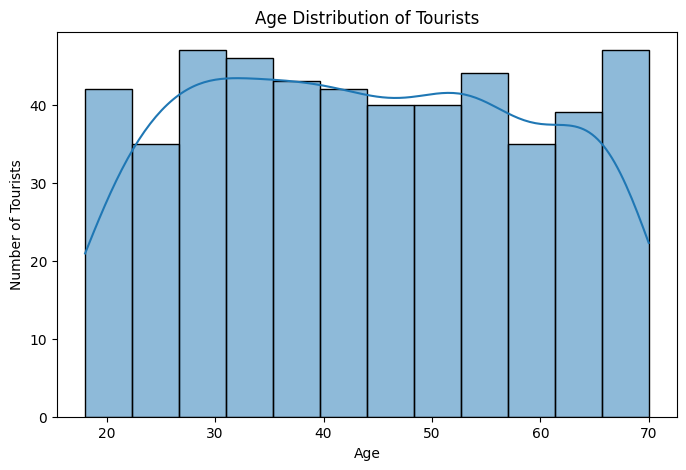

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=12, kde=True)
plt.title("Age Distribution of Tourists")
plt.xlabel("Age")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
Tourists cover a broad adult age range, allowing age-based segmentation for tourism campaigns.

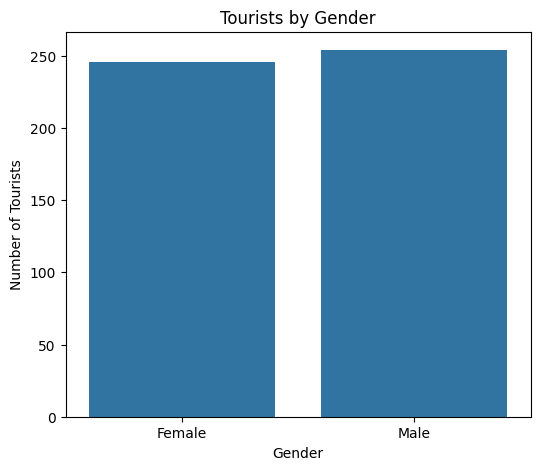

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Gender")
plt.title("Tourists by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
The dataset contains **254 male** and **246 female** tourists, indicating a nearly balanced gender distribution.

## **9. Tourist Type & Country Analysis**

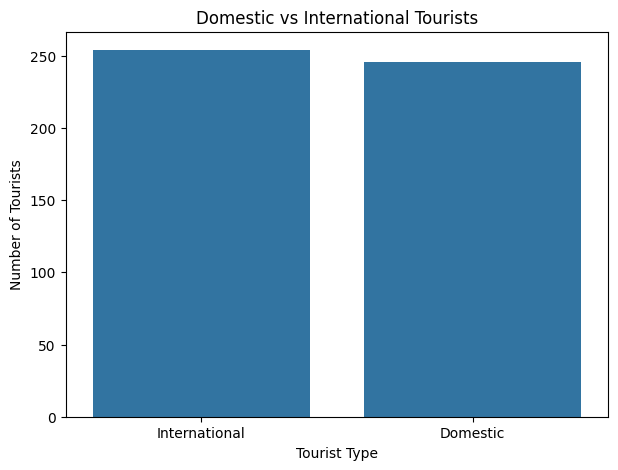

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Tourist_Type")
plt.title("Domestic vs International Tourists")
plt.xlabel("Tourist Type")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
There are **254 international** and **246 domestic** tourists, showing a relatively balanced visitor mix.

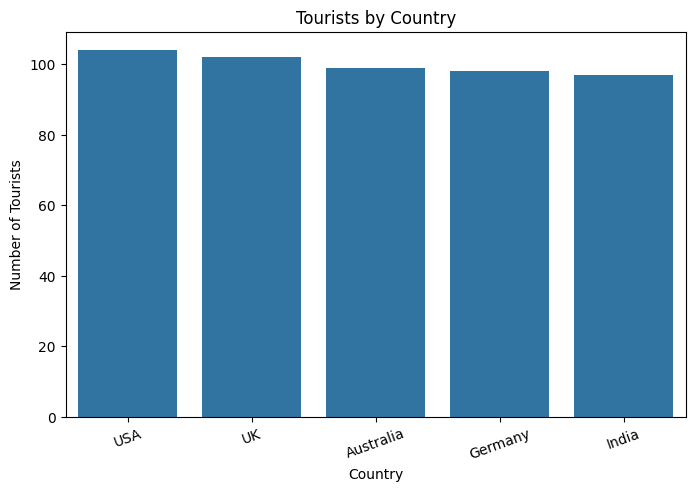

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Country", order=df["Country"].value_counts().index)
plt.title("Tourists by Country")
plt.xlabel("Country")
plt.ylabel("Number of Tourists")
plt.xticks(rotation=20)
plt.show()

### **Observation**
**USA** contributes the highest number of tourists with **104 visitors**.

## **10. Destination Analysis**

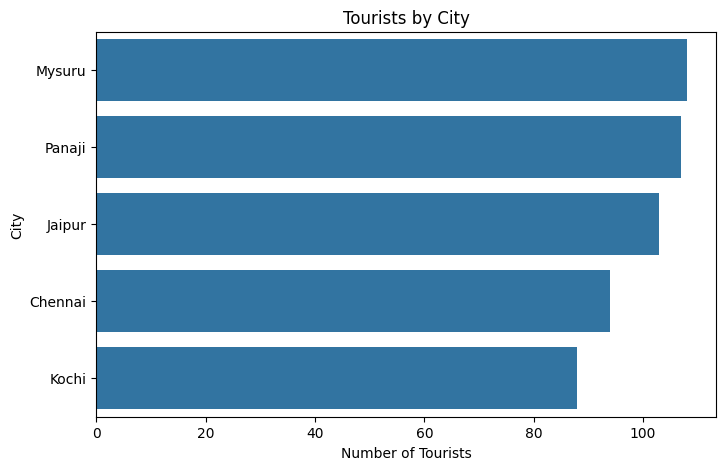

In [16]:
city_counts = df["City"].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title("Tourists by City")
plt.xlabel("Number of Tourists")
plt.ylabel("City")
plt.show()

### **Observation**
**Mysuru** has the highest visitor count with **108 tourists**, while **Kochi** has the lowest with **88**.

In [17]:
city_summary = df.groupby("City").agg(
    Tourists=("Tourist_ID","count"),
    Average_Expense=("Total_Expense","mean"),
    Average_Satisfaction=("Tourist_Satisfaction","mean")
).sort_values("Average_Expense", ascending=False)
city_summary

,Tourists,Average_Expense,Average_Satisfaction
City,,,
Chennai,94,68281.489362,7.585106
Jaipur,103,65719.669903,7.689320
Panaji,107,64848.551402,7.448598
Mysuru,108,64412.222222,7.462963
Kochi,88,64104.250000,7.295455


### **Observation**
**Chennai** has the highest average tourist expense at approximately **₹68,281**.

## **11. Purpose of Travel**

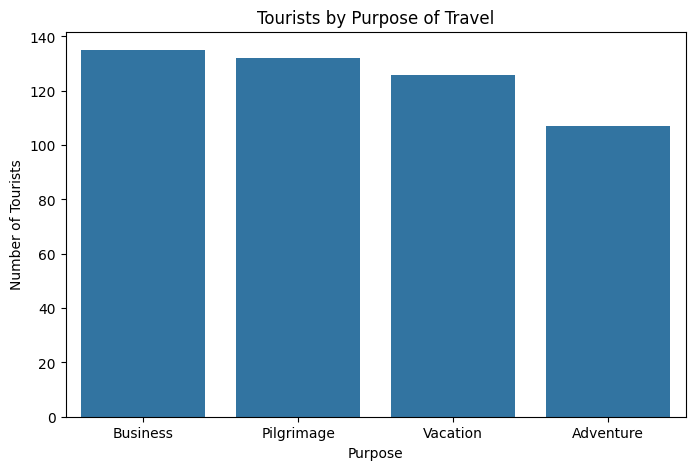

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Purpose", order=df["Purpose"].value_counts().index)
plt.title("Tourists by Purpose of Travel")
plt.xlabel("Purpose")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
**Business** is the most common travel purpose with **135 tourists**.

In [19]:
purpose_summary = df.groupby("Purpose").agg(
    Tourists=("Tourist_ID","count"),
    Average_Expense=("Total_Expense","mean"),
    Average_Days=("Days_Stayed","mean"),
    Average_Satisfaction=("Tourist_Satisfaction","mean")
).sort_values("Average_Expense", ascending=False)
purpose_summary

,Tourists,Average_Expense,Average_Days,Average_Satisfaction
Purpose,,,,
Adventure,107,66697.626168,5.785047,7.514019
Business,135,65529.355556,5.948148,7.637037
Pilgrimage,132,65185.598485,5.651515,7.560606
Vacation,126,64575.134921,5.833333,7.277778


### **Observation**
**Adventure** has the highest average spending at approximately **₹66,698**.

## **12. Seasonal & Monthly Analysis**

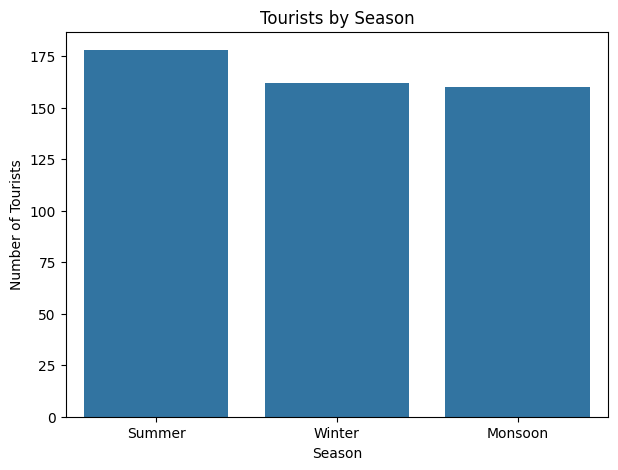

In [20]:
season_counts = df["Season"].value_counts()
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Season", order=season_counts.index)
plt.title("Tourists by Season")
plt.xlabel("Season")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
**Summer** has the highest number of tourists with **178 visitors**.

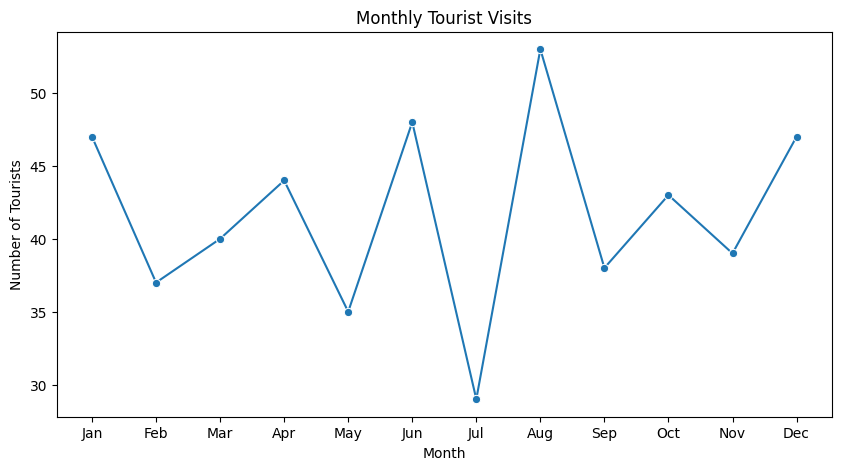

In [21]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df["Month"].value_counts().reindex(month_order)
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly.index, y=monthly.values, marker="o")
plt.title("Monthly Tourist Visits")
plt.xlabel("Month")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
The highest monthly visitor count occurs in **Aug (53 tourists)**, while the lowest occurs in **Jul (29 tourists)**.

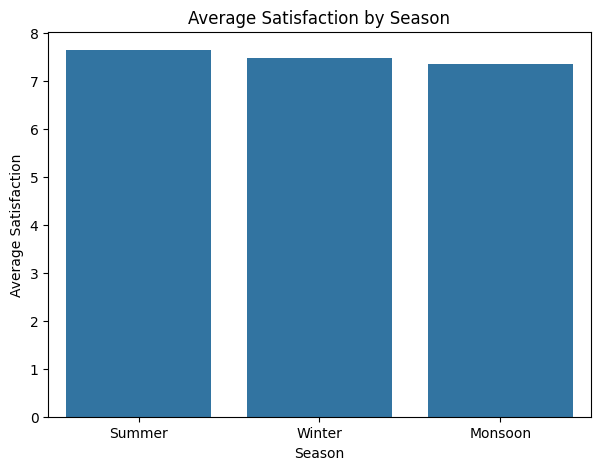

In [22]:
season_satisfaction = df.groupby("Season")["Tourist_Satisfaction"].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=season_satisfaction.index, y=season_satisfaction.values)
plt.title("Average Satisfaction by Season")
plt.xlabel("Season")
plt.ylabel("Average Satisfaction")
plt.show()

### **Observation**
**Summer** has the highest average satisfaction score at **7.65/10**.

## **13. Travel Mode Analysis**

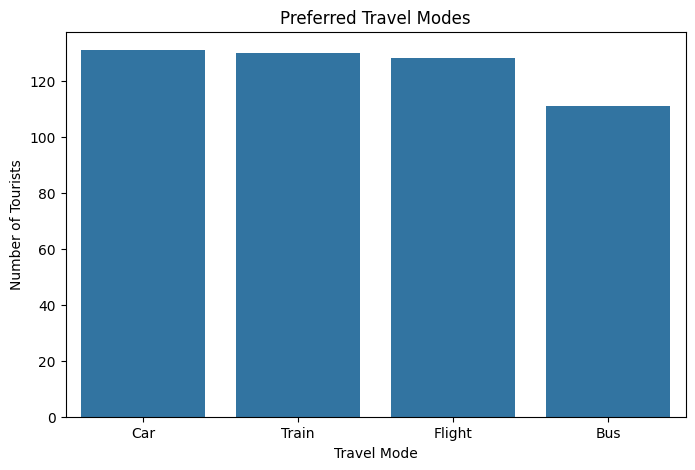

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Travel_Mode", order=df["Travel_Mode"].value_counts().index)
plt.title("Preferred Travel Modes")
plt.xlabel("Travel Mode")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
**Car** is the most frequently used travel mode with **131 tourists**.

In [24]:
travel_mode_summary = df.groupby("Travel_Mode").agg(
    Tourists=("Tourist_ID","count"),
    Average_Expense=("Total_Expense","mean"),
    Average_Satisfaction=("Tourist_Satisfaction","mean")
).sort_values("Average_Expense", ascending=False)
travel_mode_summary

,Tourists,Average_Expense,Average_Satisfaction
Travel_Mode,,,
Car,131,68782.343511,7.396947
Train,130,65910.961538,7.561538
Flight,128,63507.320312,7.656250
Bus,111,63209.243243,7.369369


### **Observation**
**Car** has the highest average tourist expense, while **Flight** has the highest average satisfaction.

## **14. Hotel Analysis**

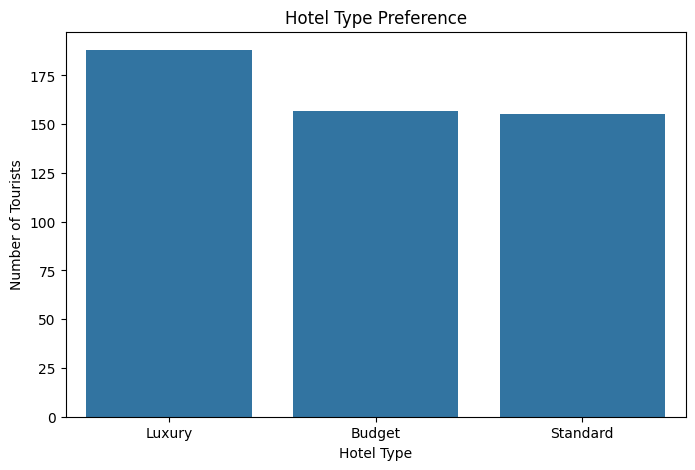

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Hotel_Type", order=df["Hotel_Type"].value_counts().index)
plt.title("Hotel Type Preference")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
**Luxury** is the most commonly selected hotel type with **188 tourists**.

In [26]:
hotel_summary = df.groupby("Hotel_Type").agg(
    Tourists=("Tourist_ID","count"),
    Average_Expense=("Total_Expense","mean"),
    Average_Rating=("Hotel_Rating","mean"),
    Average_Satisfaction=("Tourist_Satisfaction","mean")
).sort_values("Average_Expense", ascending=False)
hotel_summary

,Tourists,Average_Expense,Average_Rating,Average_Satisfaction
Hotel_Type,,,,
Standard,155,66961.767742,3.999355,7.425806
Budget,157,65742.235669,4.013376,7.566879
Luxury,188,63954.627660,3.982979,7.505319


### **Observation**
**Standard** has the highest average total expense at approximately **₹66,962**.

## **15. Expense Analysis**

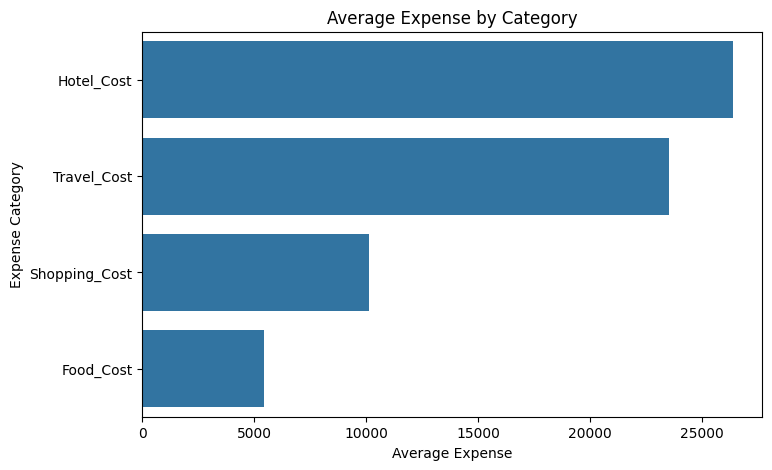

In [27]:
expense_columns = ["Travel_Cost","Hotel_Cost","Food_Cost","Shopping_Cost"]
expense_means = df[expense_columns].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=expense_means.values, y=expense_means.index)
plt.title("Average Expense by Category")
plt.xlabel("Average Expense")
plt.ylabel("Expense Category")
plt.show()

### **Observation**
**Hotel_Cost** has the highest average cost at approximately **₹26,373**.

In [28]:
print("Total Tourism Expense:", df["Total_Expense"].sum())
print("Average Tourism Expense:", df["Total_Expense"].mean())
print("Median Tourism Expense:", df["Total_Expense"].median())

Total Tourism Expense: 32724075
Average Tourism Expense: 65448.15
Median Tourism Expense: 66058.0


### **Observation**
Total recorded tourism expense is approximately **₹32,724,075**, with an average of **₹65,448 per tourist**.

## **16. Satisfaction Analysis**

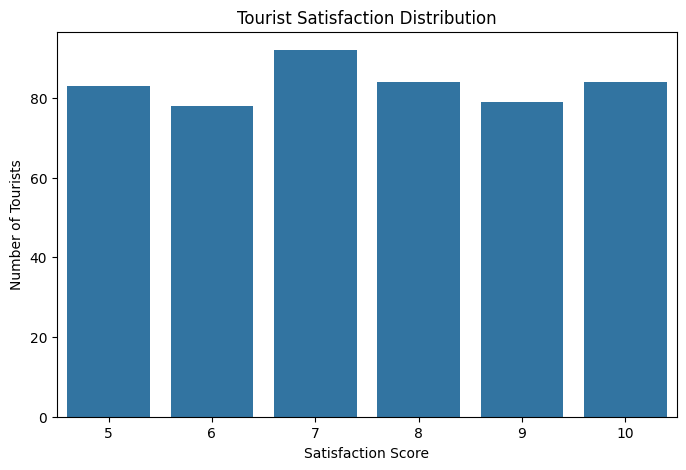

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Tourist_Satisfaction")
plt.title("Tourist Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
The average tourist satisfaction score is **7.50/10**, indicating generally positive visitor experiences.

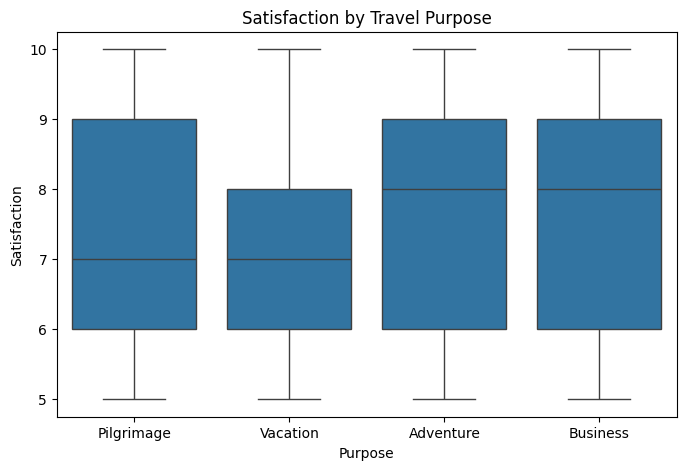

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Purpose", y="Tourist_Satisfaction")
plt.title("Satisfaction by Travel Purpose")
plt.xlabel("Purpose")
plt.ylabel("Satisfaction")
plt.show()

## **17. Booking Mode Analysis**

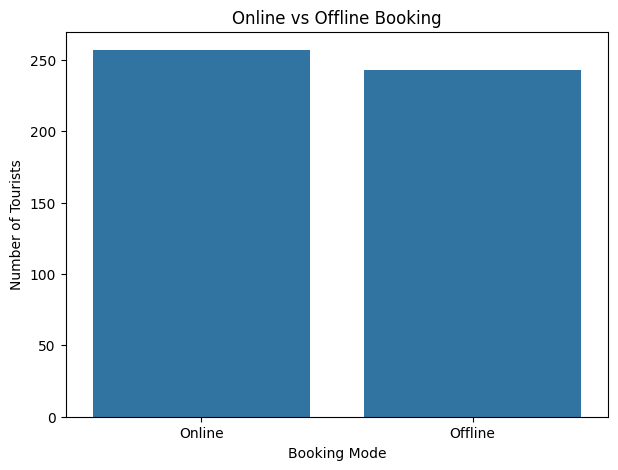

In [31]:
booking_counts = df["Booking_Mode"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=booking_counts.index, y=booking_counts.values)
plt.title("Online vs Offline Booking")
plt.xlabel("Booking Mode")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
**51.40%** of records use online booking, making it slightly more common than offline booking.

## **18. Repeat Visitor Analysis**

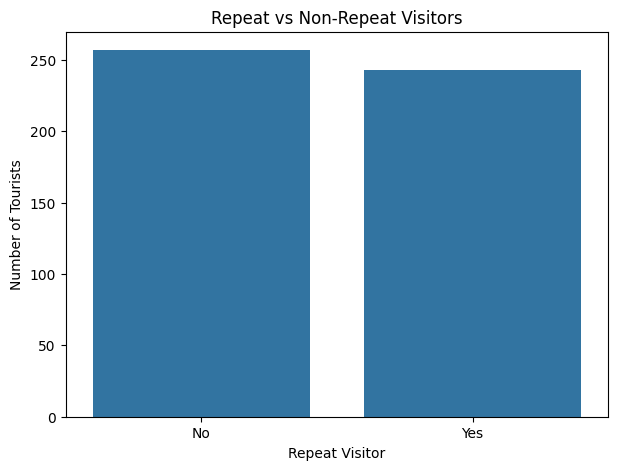

In [32]:
repeat_counts = df["Repeat_Visitor"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=repeat_counts.index, y=repeat_counts.values)
plt.title("Repeat vs Non-Repeat Visitors")
plt.xlabel("Repeat Visitor")
plt.ylabel("Number of Tourists")
plt.show()

### **Observation**
The repeat-visitor rate is **48.60%**, with **243 repeat visitors** and **257 non-repeat visitors**.

In [33]:
repeat_summary = df.groupby("Repeat_Visitor").agg(
    Tourists=("Tourist_ID","count"),
    Average_Expense=("Total_Expense","mean"),
    Average_Days=("Days_Stayed","mean"),
    Average_Satisfaction=("Tourist_Satisfaction","mean")
)
repeat_summary

,Tourists,Average_Expense,Average_Days,Average_Satisfaction
Repeat_Visitor,,,,
No,257,64814.809339,5.595331,7.447471
Yes,243,66117.979424,6.028807,7.555556


### **Observation**
Repeat visitors spend approximately **₹66,118** on average versus **₹64,815** for non-repeat visitors, and they stay slightly longer.

## **19. Repeat Visitor Behaviour by City**

In [34]:
city_repeat = df.assign(
    Repeat_Flag=df["Repeat_Visitor"].eq("Yes")
).groupby("City").agg(
    Tourists=("Tourist_ID","count"),
    Repeat_Visitors=("Repeat_Flag","sum"),
    Repeat_Rate=("Repeat_Flag","mean"),
    Average_Expense=("Total_Expense","mean")
).sort_values("Repeat_Rate", ascending=False)
city_repeat

,Tourists,Repeat_Visitors,Repeat_Rate,Average_Expense
City,,,,
Chennai,94,56,0.595745,68281.489362
Mysuru,108,57,0.527778,64412.222222
Jaipur,103,48,0.466019,65719.669903
Panaji,107,46,0.429907,64848.551402
Kochi,88,36,0.409091,64104.250000


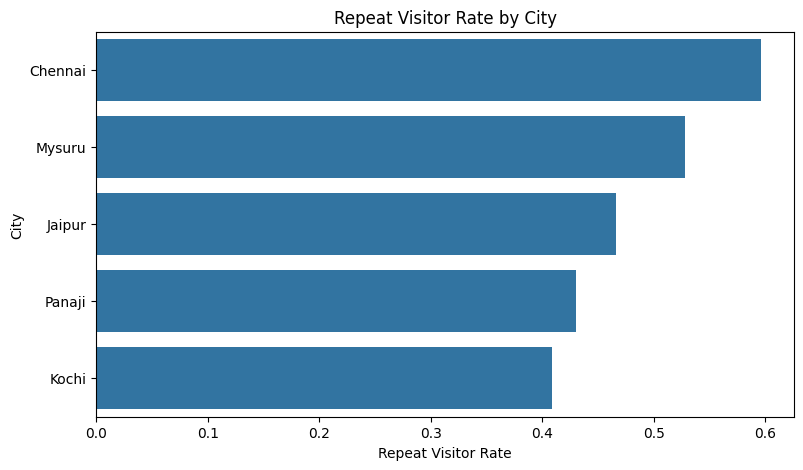

In [35]:
plt.figure(figsize=(9,5))
sns.barplot(data=city_repeat.reset_index(), x="Repeat_Rate", y="City")
plt.title("Repeat Visitor Rate by City")
plt.xlabel("Repeat Visitor Rate")
plt.ylabel("City")
plt.show()

### **Observation**
**Chennai** has the strongest repeat-visitor rate at approximately **59.57%**, while **Kochi** has the lowest.

## **20. Correlation Analysis**

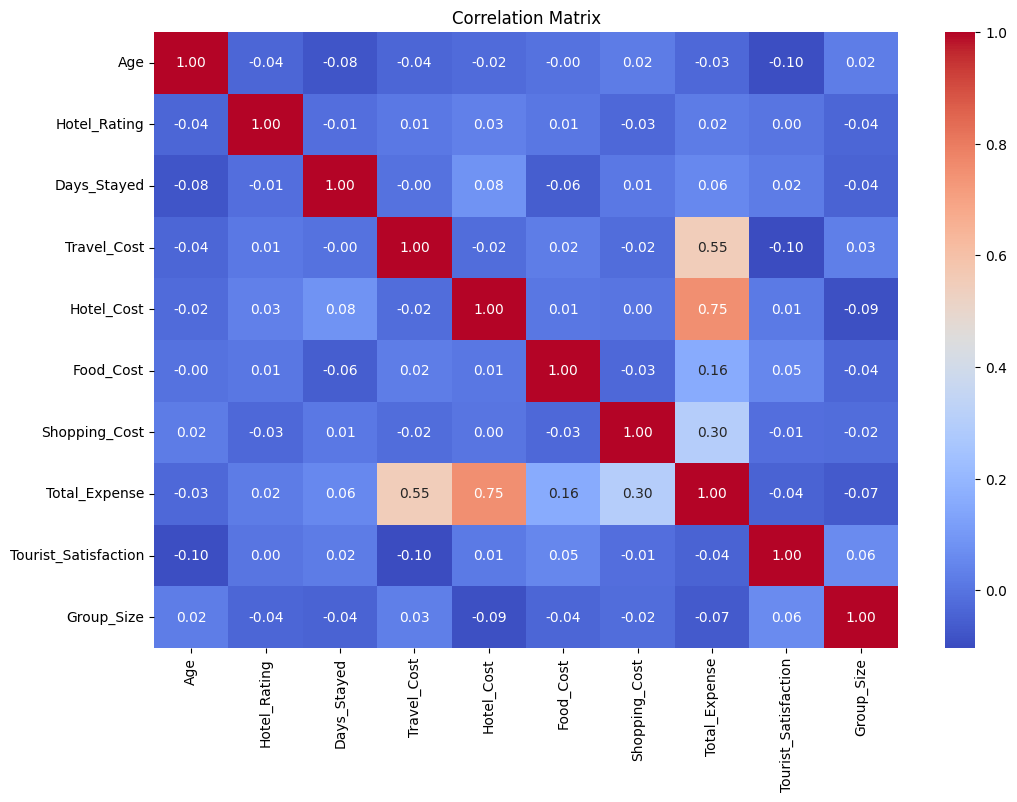

In [36]:
numeric_cols = [
    "Age","Hotel_Rating","Days_Stayed","Travel_Cost","Hotel_Cost",
    "Food_Cost","Shopping_Cost","Total_Expense",
    "Tourist_Satisfaction","Group_Size"
]
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### **Observation**
The correlation matrix helps identify associations among stay duration, expense components, total expense, satisfaction, age, and group size. Correlation should be interpreted as association rather than proof of causation.

# **21. Business Insights**

1. **Balanced visitor profile:** Male and female tourist representation is almost equal.
2. **Domestic and international mix:** Both visitor types are important because their representation is nearly balanced.
3. **Destination spending:** Chennai has the highest average tourist expense among the listed cities.
4. **Purpose-driven spending:** Adventure travellers have the highest average expense.
5. **Seasonality:** Summer has the highest visitor volume, while Monsoon has the highest average spending.
6. **Travel behaviour:** Car is the most frequently used travel mode, while Flight users have the highest average satisfaction.
7. **Accommodation:** Luxury hotels are the most commonly selected, while Standard hotels have the highest average total expense.
8. **Booking behaviour:** Online booking is slightly more common than offline booking.
9. **Repeat visitation:** Repeat visitors represent nearly half of the dataset and spend slightly more and stay longer on average.
10. **City retention:** Chennai has the strongest repeat-visitor rate, while Kochi has the weakest among the five cities.
11. **Customer experience:** Overall average satisfaction is 7.5/10.


# **22. Recommendations**

### 1. Strengthen high-value tourism segments
Promote adventure-focused packages because this segment has the highest average spending.

### 2. Improve destination-level marketing
Use city-level spending and repeat-visitor rates to create targeted campaigns and retention offers.

### 3. Promote digital booking
Continue improving online booking convenience, mobile experience, digital offers, and online support.

### 4. Build repeat-visitor programmes
Use loyalty discounts, return-visit rewards, personalised recommendations, and exclusive packages.

### 5. Use seasonal pricing and promotions
Use demand-based packages during high-volume Summer and targeted premium offers during higher-spending Monsoon periods.

### 6. Focus on customer experience
Monitor satisfaction by city, purpose, travel mode, and hotel type to identify opportunities for service improvement.

### 7. Cross-sell tourism services
Create bundled packages combining accommodation, transport, meals, activities, and shopping benefits.


# **23. Conclusion**

This exploratory analysis provides an overall understanding of tourist demographics, destinations, travel purposes, seasonal patterns, accommodation preferences, expenses, satisfaction, booking behaviour, and repeat visitation.

The dataset shows a balanced domestic and international visitor base, varied travel purposes, meaningful differences in spending across cities and segments, and a substantial proportion of repeat visitors. Online booking is slightly more popular than offline booking, while repeat visitors show slightly higher spending and stay duration.

The analysis demonstrates how EDA can convert raw tourism data into useful business insights for destination marketing, customer retention, pricing, service improvement, and tourism planning.
